# LIBRARY

In [32]:
import gzip
import pickle
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import squareform, cdist, pdist

from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import cdist_dtw

from matplotlib.patches import Patch
from matplotlib.cm import get_cmap

warnings.filterwarnings("ignore")

# PREPARATION

## LOAD DATASET

In [33]:
MOTIFS_CSV   = "../1.DATASET/motifs_discords.csv"
DATASET_PATH = "../1.DATASET/CMI_timeseries_personalized.pkl.gz"
CHANNELS     = ["X", "Y", "Z", "enmo", "anglez", "light"]
W            = 17
COLS_TO_DROP = ["battery_voltage", "timestamp", "quarter",
                "relative_date_PCIAT", "non-wear_flag", "weekday"]
USE_DISCORDS = False

In [34]:
with gzip.open(DATASET_PATH, "rb") as f:
    CMI = pickle.load(f)

data_clean = [df.drop(columns=COLS_TO_DROP, errors="ignore") for df in CMI]
print(f"  {len(data_clean)} subjects loaded")

# Extract sii_binary labels BEFORE dropping columns
y_labels = np.array([
    df["sii_binary"].dropna().iloc[0]
    if "sii_binary" in df.columns else np.nan
    for df in CMI
], dtype=float)

print(f"  Labels extracted: {len(y_labels)} subjects")
print(f"  label=0: {(y_labels==0).sum()}  label=1: {(y_labels==1).sum()}  NaN: {np.isnan(y_labels).sum()}")

  4307 subjects loaded
  Labels extracted: 4307 subjects
  label=0: 2887  label=1: 1420  NaN: 0


## NORMALIZATION

In [5]:
signals = ["X", "Y", "Z", "enmo", "anglez", "light"]

In [36]:

def fit_global_scalers(df_list, signals):
    global_scalers = {}
    print("Fitting global scalers on train data...")
    for signal in signals:
        all_values = []
        for df in df_list:
            if signal not in df.columns:
                continue
            y = df[signal].values
            if np.std(y) < 0.0001 or np.ptp(y) == 0:
                continue
            all_values.append(y)
        if not all_values:
            continue
        population = np.concatenate(all_values).reshape(-1, 1)
        q25, q75   = np.percentile(population, [25, 75])
        iqr        = q75 - q25
        signal_std = np.std(population)
        if iqr > 1e-4:
            scaler = RobustScaler()
            scaler.fit(population)
            global_scalers[signal] = ("robust", scaler)
            print(f"  {signal:<18} → RobustScaler   (IQR={iqr:.4f})")
        elif signal_std > 1e-6:
            global_scalers[signal] = ("std_fallback", np.median(population), signal_std)
            print(f"  {signal:<18} → Std fallback   (IQR too small)")
        else:
            global_scalers[signal] = ("zero", None)
            print(f"  {signal:<18} → Zeroed")
    return global_scalers

In [37]:
def apply_global_scalers(df_list, global_scalers):
    scaled_list = []
    for df in df_list:
        target_df = df.copy()
        for signal, scaler_info in global_scalers.items():
            if signal not in target_df.columns:
                continue
            y    = target_df[signal].values.copy()
            kind = scaler_info[0]
            if kind == "robust":
                _, scaler = scaler_info
                y_scaled  = scaler.transform(y.reshape(-1, 1)).flatten()
            elif kind == "std_fallback":
                _, median, std = scaler_info
                y_scaled  = (y - median) / std
            else:
                y_scaled  = np.zeros_like(y)
            target_df[signal] = y_scaled
        scaled_list.append(target_df)
    return scaled_list



In [38]:
signals = ["X", "Y", "Z", "enmo", "anglez", "light"]

global_scalers = fit_global_scalers(data_clean, signals)
all_scaled     = apply_global_scalers(data_clean, global_scalers)

Fitting global scalers on train data...
  X                  → RobustScaler   (IQR=0.8341)
  Y                  → RobustScaler   (IQR=0.4156)
  Z                  → RobustScaler   (IQR=0.4314)
  enmo               → RobustScaler   (IQR=0.0454)
  anglez             → RobustScaler   (IQR=5.6440)
  light              → RobustScaler   (IQR=1.8208)


## LOAD MOTIF DATASET

In [39]:
print("Loading motifs CSV ...")
motifs_df = pd.read_csv(MOTIFS_CSV)

for col in motifs_df.columns:
    if col != "sample_index":
        motifs_df[col] = motifs_df[col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )

print(motifs_df.shape)
motifs_df.head()

Loading motifs CSV ...
(4307, 13)


,sample_index,X_motifs,X_discords,Y_motifs,Y_discords,Z_motifs,Z_discords,enmo_motifs,enmo_discords,anglez_motifs,anglez_discords,light_motifs,light_discords
0,0,"[34, 72, 67, 163, 118, 117]","[7, 12, 109]","[44, 190, 164, 182, 166, 22]","[146, 147, 115]","[67, 144, 146, 69, 66, 143]","[171, 47, 131]","[2, 69, 70, 3, 4, 71]","[138, 137, 111]","[1, 76, 71, 21, 184, 148]","[132, 134, 47]","[115, 133, 116, 150, 154, 13]","[88, 98, 24]"
1,1,"[2, 106, 15, 189, 187, 13]","[72, 71, 96]","[0, 49, 48, 44, 137, 46]","[156, 163, 6]","[100, 186, 122, 18, 121, 17]","[137, 140, 117]","[124, 189, 140, 111, 110, 139]","[100, 99, 101]","[123, 160, 159, 122, 120, 79]","[104, 117, 135]","[24, 30, 28, 23, 29, 8]","[77, 86, 81]"
2,2,"[114, 158, 157, 113, 10, 156]","[190, 26, 87]","[5, 71, 123, 16, 9, 97]","[26, 180, 52]","[31, 127, 32, 128, 129, 33]","[39, 177, 176]","[97, 114, 113, 96, 107, 150]","[62, 131, 140]","[79, 153, 129, 125, 50, 115]","[11, 10, 64]","[0, 20, 22, 14, 13, 17]","[80, 81, 79]"
3,3,"[26, 124, 55, 148, 127, 54]","[11, 12, 118]","[52, 79, 69, 103, 24, 187]","[60, 137, 33]","[83, 162, 163, 84, 47, 181]","[186, 95, 67]","[0, 56, 41, 82, 55, 148]","[115, 114, 112]","[1, 53, 54, 2, 23, 44]","[60, 67, 95]","[5, 27, 31, 7, 10, 20]","[102, 177, 178]"
4,4,"[13, 67, 15, 7, 68, 14]","[46, 47, 84]","[12, 78, 45, 18, 44, 17]","[175, 148, 121]","[175, 187, 6, 25, 177, 189]","[34, 111, 90]","[54, 73, 72, 53, 77, 131]","[175, 86, 38]","[175, 187, 22, 85, 28, 169]","[140, 91, 42]","[0, 1, 2, 3, 4, 5]","[161, 93, 61]"


## SIGNAL RETRIEVAL

In [99]:
# For every subject, for every channel, pull the raw windows
# at each motif start index  →  store as fixed-length vectors

In [40]:
def extract_windows(ts: np.ndarray, indices: list, w: int) -> list:
    windows = []
    for idx in indices:
        if idx + w <= len(ts):
            windows.append(ts[idx: idx + w])
    return windows

In [41]:
def motif_medoid(windows: list) -> np.ndarray:
    if len(windows) == 0:
        return None
    if len(windows) == 1:
        return windows[0]
    X = np.vstack(windows)
    D = cdist(X, X, metric="euclidean")
    return X[np.argmin(D.sum(axis=1))]

In [42]:
records = []

for _, row in motifs_df.iterrows():
    subj_idx  = int(row["sample_index"])
    df_subj   = all_scaled[subj_idx]
    subj_features = {"sample_index": subj_idx}

    for ch in CHANNELS:
        if ch not in df_subj.columns:
            subj_features[f"{ch}_motif_medoid"]   = np.zeros(W)
            subj_features[f"{ch}_discord_medoid"] = np.zeros(W)
            continue

        ts           = df_subj[ch].values.astype(float)
        motif_idxs   = row[f"{ch}_motifs"]
        discord_idxs = row[f"{ch}_discords"]

        motif_wins   = extract_windows(ts, motif_idxs,   W)
        discord_wins = extract_windows(ts, discord_idxs, W)

        subj_features[f"{ch}_motif_medoid"]   = (
            motif_medoid(motif_wins)   if motif_wins   else np.zeros(W)
        )
        subj_features[f"{ch}_discord_medoid"] = (
            motif_medoid(discord_wins) if discord_wins else np.zeros(W)
        )

    records.append(subj_features)

print(f"  Built {len(records)} subject records")

  Built 4307 subject records


## BUILD 3D FEATURE MATRIX

In [43]:
if USE_DISCORDS:
    X_3d = np.array([
        np.hstack([
            np.stack([r[f"{ch}_motif_medoid"]   for ch in CHANNELS], axis=1),
            np.stack([r[f"{ch}_discord_medoid"] for ch in CHANNELS], axis=1),
        ])
        for r in records
    ])
    print(f"Feature matrix shape (motifs + discords): {X_3d.shape}")
else:
    X_3d = np.array([
        np.stack([r[f"{ch}_motif_medoid"] for ch in CHANNELS], axis=1)
        for r in records
    ])
    print(f"Feature matrix shape (motifs only): {X_3d.shape}")

Feature matrix shape (motifs only): (4307, 17, 6)


# Hierarchical clustering

## distance matrix

In [56]:
print("Computing DTW distance matrix (this may take a while) ...")
sakoe_radius = 10
dist_mat = cdist_dtw(
    X_3d,
    global_constraint="sakoe_chiba",
    sakoe_chiba_radius=sakoe_radius
)
print(f"  Distance matrix shape: {dist_mat.shape}")

print("Building linkage matrix ...")
condensed = squareform(dist_mat)
Z         = linkage(condensed, method="ward")   # complete/average valid for DTW; ward is not
print("  Done.")


Computing DTW distance matrix (this may take a while) ...
  Distance matrix shape: (4307, 4307)
Building linkage matrix ...
  Done.


## OPTIMAL NUMBER OF CLUSTERS

## SWEEP k  →  silhouette + SSE on precomputed dist_mat



Sweeping k ...
  k= 2  silhouette=0.9819  SSE=666954.17
  k= 3  silhouette=0.6828  SSE=564582.03
  k= 4  silhouette=0.4369  SSE=475436.40
  k= 5  silhouette=0.4523  SSE=414018.75
  k= 6  silhouette=0.4545  SSE=381795.85
  k= 7  silhouette=0.2732  SSE=351928.90
  k= 8  silhouette=0.2733  SSE=333528.51
  k= 9  silhouette=0.2825  SSE=319723.74
  k=10  silhouette=0.2826  SSE=308053.07
  k=11  silhouette=0.2587  SSE=296700.52
  k=12  silhouette=0.2543  SSE=287360.46
  k=13  silhouette=0.0924  SSE=278688.70
  k=14  silhouette=0.0925  SSE=271447.95
  k=15  silhouette=0.0802  SSE=264540.09
  k=16  silhouette=0.0813  SSE=258476.38

  → Best k by silhouette: 2


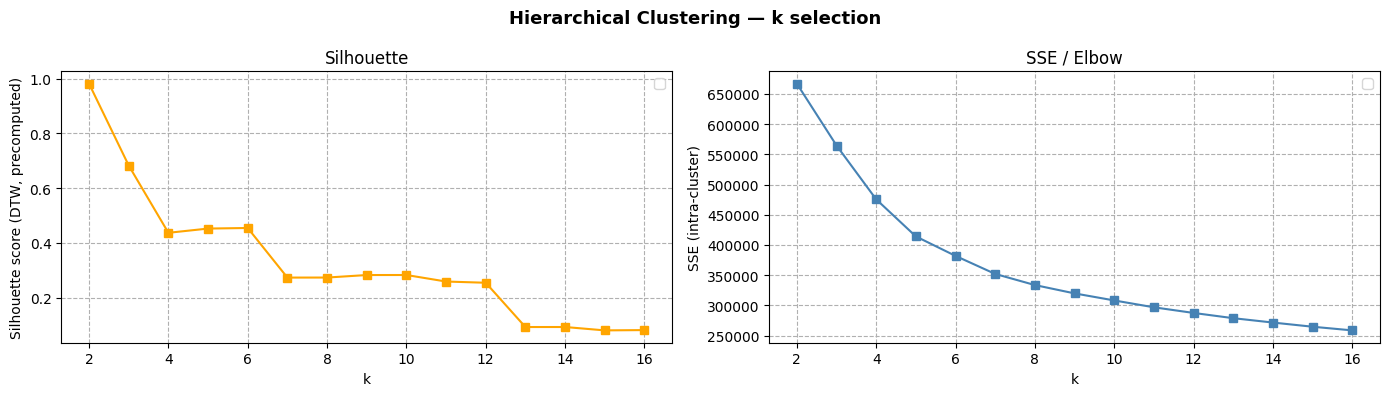

In [57]:
k_range  = range(2, 17)
sil_list = []
sse_list = []

print("\nSweeping k ...")
for k in k_range:
    labels = fcluster(Z, t=k, criterion="maxclust") - 1   # 0-indexed

    sil = silhouette_score(dist_mat, labels, metric="precomputed")
    sil_list.append(sil)

    sse = 0.0
    for c in range(k):
        mask     = np.where(labels == c)[0]
        sub_dist = dist_mat[np.ix_(mask, mask)]
        sse += (sub_dist ** 2).sum() / (2 * len(mask)) if len(mask) > 0 else 0
    sse_list.append(sse)

    print(f"  k={k:2d}  silhouette={sil:.4f}  SSE={sse:.2f}")

auto_best_k = list(k_range)[int(np.argmax(sil_list))]
print(f"\n  → Best k by silhouette: {auto_best_k}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Hierarchical Clustering — k selection", fontsize=13, fontweight="bold")

ax1.plot(list(k_range), sil_list, "s-", color="orange")
ax1.set_xlabel("k")
ax1.set_ylabel("Silhouette score (DTW, precomputed)")
ax1.set_title("Silhouette")
ax1.legend()
ax1.grid(linestyle="--")

ax2.plot(list(k_range), sse_list, "s-", color="steelblue")
ax2.set_xlabel("k")
ax2.set_ylabel("SSE (intra-cluster)")
ax2.set_title("SSE / Elbow")
ax2.legend()
ax2.grid(linestyle="--")

plt.tight_layout()
plt.show()

In [58]:
best_k = 10   # set based on silhouette/elbow plots above

cluster_labels = fcluster(Z, best_k, criterion="maxclust") - 1   # 0-indexed, shape (n_subjects,)

print(f"Cluster labels assigned for k={best_k}")
print(f"Unique clusters: {np.unique(cluster_labels)}")
print(f"Counts: {np.bincount(cluster_labels)}")

Cluster labels assigned for k=10
Unique clusters: [0 1 2 3 4 5 6 7 8 9]
Counts: [  40   29    6    1  381  159  336   63 3291    1]


## DENDROGRAM

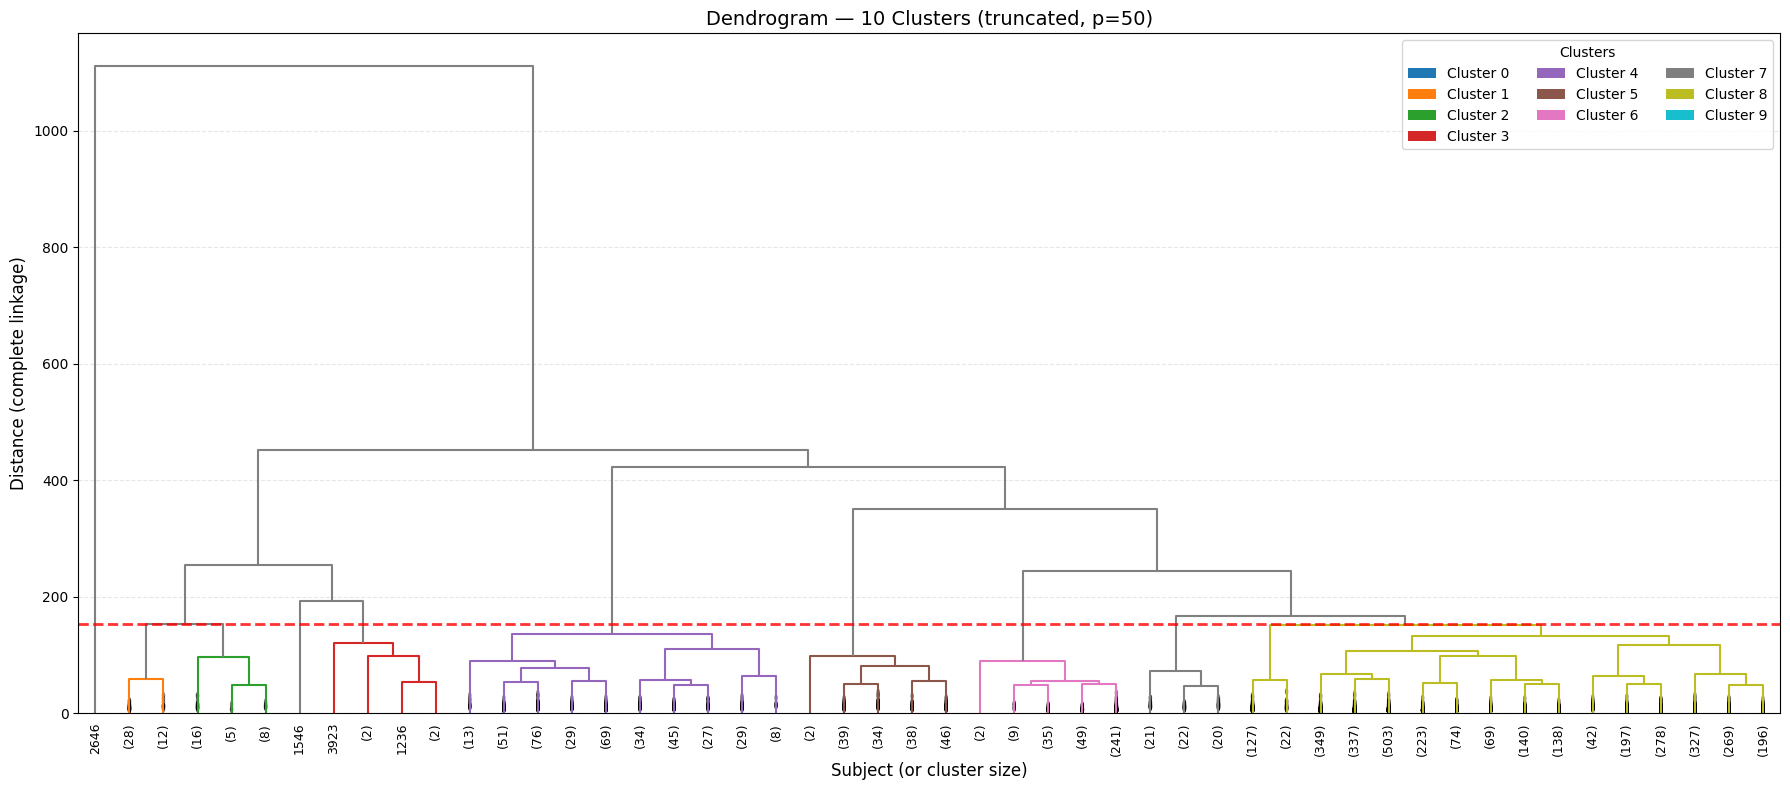

In [59]:
from scipy.cluster.hierarchy import fcluster

cmap_d = get_cmap("tab10")
colors = [cmap_d(i % 10) for i in range(best_k)]

fig, ax = plt.subplots(figsize=(18, 8))

cut_height = Z[-(best_k - 1), 2]

R = dendrogram(
    Z,
    truncate_mode="lastp",
    p=50,
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=cut_height,
    above_threshold_color="gray"
)

ax.axhline(y=cut_height, color="red", linestyle="--", linewidth=2, alpha=0.8)

# ── Map truncated leaves to cluster labels ────────────────────────────
# In lastp mode, leaves are linkage node IDs, not subject indices.
# For each node, find all original subjects underneath it and take
# the majority cluster label.
n_subjects = len(cluster_labels)

def get_subjects_under_node(node_id, Z, n_subjects):
    """Recursively collect all original leaf indices under a linkage node."""
    if node_id < n_subjects:
        return [node_id]
    left  = int(Z[node_id - n_subjects, 0])
    right = int(Z[node_id - n_subjects, 1])
    return get_subjects_under_node(left, Z, n_subjects) + \
           get_subjects_under_node(right, Z, n_subjects)

leaf_order = R["leaves"]
y_min, y_max = ax.get_ylim()
bar_height = (y_max - y_min) * 0.02
bar_y      = y_min - bar_height * 2

for i, leaf in enumerate(leaf_order):
    if leaf < n_subjects:
        # Single subject — direct lookup
        c = cluster_labels[leaf]
    else:
        # Merged node — majority vote among subjects underneath
        subjects = get_subjects_under_node(leaf, Z, n_subjects)
        counts   = np.bincount([cluster_labels[s] for s in subjects], minlength=best_k)
        c        = int(np.argmax(counts))

    color = colors[c % best_k]
    ax.fill_between([i - 0.5, i + 0.5], bar_y, bar_y + bar_height,
                    color=color, alpha=0.8)

legend_elements = [Patch(facecolor=colors[i], label=f"Cluster {i}")
                   for i in range(best_k)]
ax.legend(handles=legend_elements, loc="upper right",
          title="Clusters", ncol=3, fontsize=10)

ax.set_xlabel("Subject (or cluster size)", fontsize=12)
ax.set_ylabel("Distance (complete linkage)", fontsize=12)
ax.set_title(f"Dendrogram — {best_k} Clusters (truncated, p=50)", fontsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## CLUSTER ANALYSIS

In [60]:
motifs_df["cluster_hier"] = cluster_labels

print("\n" + "="*50)
print("CLUSTER ANALYSIS")
print("="*50)

cluster_counts = motifs_df["cluster_hier"].value_counts().sort_index()
for c, n in cluster_counts.items():
    print(f"  Cluster {c}: {n:4d} subjects  ({100*n/len(motifs_df):.1f}%)")

print("\n--- Subject indices per cluster (first 10 shown) ---")
for c in range(best_k):
    members = motifs_df.loc[motifs_df["cluster_hier"] == c, "sample_index"].tolist()
    print(f"  Cluster {c} ({len(members)} subjects): "
          f"{members[:10]}{'...' if len(members) > 10 else ''}")

print("\n--- Most central subject per cluster (by avg DTW dist) ---")
for c in range(best_k):
    mask     = np.where(cluster_labels == c)[0]
    sub_dist = dist_mat[np.ix_(mask, mask)]
    central  = mask[np.argmin(sub_dist.mean(axis=1))]
    print(f"  Cluster {c}: most central subject = sample_index "
          f"{motifs_df.iloc[central]['sample_index']}  "
          f"(avg DTW dist = {sub_dist.mean(axis=1).min():.4f})")

print("\n--- Centroid motif shape summary (mean ± std across cluster members) ---")
for c in range(best_k):
    mask = cluster_labels == c
    print(f"\n  Cluster {c}  (n={mask.sum()}):")
    for i, ch in enumerate(CHANNELS):
        ch_windows = X_3d[mask, :, i]
        mean_pat   = ch_windows.mean(axis=0)
        print(f"    {ch:>8s}: mean={mean_pat.mean():.4f}  "
              f"std={ch_windows.std():.4f}  "
              f"min={mean_pat.min():.4f}  max={mean_pat.max():.4f}")


CLUSTER ANALYSIS
  Cluster 0:   40 subjects  (0.9%)
  Cluster 1:   29 subjects  (0.7%)
  Cluster 2:    6 subjects  (0.1%)
  Cluster 3:    1 subjects  (0.0%)
  Cluster 4:  381 subjects  (8.8%)
  Cluster 5:  159 subjects  (3.7%)
  Cluster 6:  336 subjects  (7.8%)
  Cluster 7:   63 subjects  (1.5%)
  Cluster 8: 3291 subjects  (76.4%)
  Cluster 9:    1 subjects  (0.0%)

--- Subject indices per cluster (first 10 shown) ---
  Cluster 0 (40 subjects): [101, 215, 428, 558, 657, 660, 720, 741, 782, 830]...
  Cluster 1 (29 subjects): [38, 75, 91, 301, 358, 418, 473, 484, 847, 996]...
  Cluster 2 (6 subjects): [916, 1236, 1852, 2962, 3280, 3923]
  Cluster 3 (1 subjects): [1546]
  Cluster 4 (381 subjects): [22, 25, 26, 62, 64, 68, 92, 118, 129, 145]...
  Cluster 5 (159 subjects): [24, 28, 148, 238, 246, 254, 289, 290, 338, 369]...
  Cluster 6 (336 subjects): [18, 19, 20, 57, 61, 63, 65, 83, 86, 95]...
  Cluster 7 (63 subjects): [13, 46, 98, 134, 186, 213, 385, 493, 591, 676]...
  Cluster 8 (3291 

In [61]:
def characterize_clusters(
    motifs_df: pd.DataFrame,
    X_3d: np.ndarray,
    km_final,
    CHANNELS: list,
    best_k: int,
    y_labels: np.ndarray = None,
    figsize_per_cluster: tuple = (14, 3),
    save_path: str = None,
):
    centroids  = km_final.cluster_centers_
    W          = X_3d.shape[1]
    n_channels = X_3d.shape[2]
    time_axis  = np.arange(W)
    cmap       = get_cmap("tab10")

    # ------------------------------------------------------------------ #
    # 1. Cluster sizes
    # ------------------------------------------------------------------ #
    print("\n" + "=" * 60)
    print("  CLUSTER ANALYSIS")
    print("=" * 60)

    print("\n--- Cluster sizes ---")
    cluster_counts = motifs_df["cluster"].value_counts().sort_index()
    for c, n in cluster_counts.items():
        pct = 100 * n / len(motifs_df)
        print(f"  Cluster {c}: {n:4d} subjects  ({pct:.1f}%)")

    # ------------------------------------------------------------------ #
    # 2. Label distribution
    # ------------------------------------------------------------------ #
    label_stats = {}
    if y_labels is not None:
        print("\n--- Label distribution per cluster (sii_binary) ---")
        for c in range(best_k):
            members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
            labels_c    = y_labels[members_idx]
            n0    = int((labels_c == 0).sum())
            n1    = int((labels_c == 1).sum())
            total = len(labels_c)
            pct0  = 100 * n0 / total if total > 0 else 0
            pct1  = 100 * n1 / total if total > 0 else 0
            label_stats[c] = {"n0": n0, "n1": n1, "pct0": pct0, "pct1": pct1}
            print(
                f"  Cluster {c}: "
                f"label=0 → {n0:4d} ({pct0:.1f}%)   "
                f"label=1 → {n1:4d} ({pct1:.1f}%)   "
                f"[majority: {'0' if n0 >= n1 else '1'}]"
            )

    # ------------------------------------------------------------------ #
    # 3. Centroid stats
    # ------------------------------------------------------------------ #
    print("\n--- Centroid summary (mean ± std across time steps, per channel) ---")
    for c in range(best_k):
        print(f"\n  Cluster {c}  ({cluster_counts[c]} subjects):")
        for i, ch in enumerate(CHANNELS):
            vals = centroids[c, :, i]
            print(
                f"    {ch:>10s}:  mean={vals.mean():+.4f}  std={vals.std():.4f}"
                f"  min={vals.min():+.4f}  max={vals.max():+.4f}"
            )

    # ------------------------------------------------------------------ #
    # 4. Intra-cluster cohesion
    # ------------------------------------------------------------------ #
    print("\n--- Intra-cluster cohesion (Euclidean dist to mean centroid) ---")
    all_flat  = X_3d.reshape(len(X_3d), -1)
    cent_flat = centroids.reshape(best_k, -1)

    intra_stats = {}
    for c in range(best_k):
        members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
        member_data = all_flat[members_idx]
        dists       = cdist(member_data, cent_flat[[c]], metric="euclidean").ravel()
        intra_stats[c] = {
            "mean_dist": dists.mean(), "std_dist": dists.std(),
            "max_dist":  dists.max(),  "min_dist": dists.min(),
        }
        print(f"  Cluster {c}: mean_dist={dists.mean():.4f}  std={dists.std():.4f}  "
              f"min={dists.min():.4f}  max={dists.max():.4f}")

    # ------------------------------------------------------------------ #
    # 5. Inter-cluster distances
    # ------------------------------------------------------------------ #
    print("\n--- Inter-cluster centroid distances (Euclidean, mean centroids) ---")
    inter = cdist(cent_flat, cent_flat, metric="euclidean")
    for i in range(best_k):
        for j in range(i + 1, best_k):
            print(f"  Cluster {i} <-> Cluster {j}: {inter[i, j]:.4f}")

    # ------------------------------------------------------------------ #
    # PLOT A — centroid motifs per cluster
    # ------------------------------------------------------------------ #
    fig_h = figsize_per_cluster[1] * best_k
    fig, axes = plt.subplots(best_k, n_channels,
                             figsize=(figsize_per_cluster[0], fig_h), sharex=True)
    if best_k == 1:
        axes = axes[np.newaxis, :]

    for c in range(best_k):
        members_idx = motifs_df.loc[motifs_df["cluster"] == c, "sample_index"].tolist()
        color       = cmap(c % 10)

        for i, ch in enumerate(CHANNELS):
            ax = axes[c, i]
            for idx in members_idx:
                ax.plot(time_axis, X_3d[idx, :, i], color=color, alpha=0.15, linewidth=0.6)
            ax.plot(time_axis, centroids[c, :, i], color=color, linewidth=2.2, label="centroid")

            member_data = X_3d[members_idx, :, i]
            mean_band   = member_data.mean(axis=0)
            std_band    = member_data.std(axis=0)
            ax.fill_between(time_axis, mean_band - std_band, mean_band + std_band,
                            color=color, alpha=0.12)

            if c == 0:
                ax.set_title(ch, fontsize=9, fontweight="bold")
            if i == 0:
                if y_labels is not None and c in label_stats:
                    s = label_stats[c]
                    ax.set_ylabel(f"Cluster {c}\n(n={len(members_idx)})\n0:{s['n0']} 1:{s['n1']}",
                                  fontsize=8, labelpad=4)
                else:
                    ax.set_ylabel(f"Cluster {c}\n(n={len(members_idx)})", fontsize=8, labelpad=4)
            ax.tick_params(labelsize=7)
            ax.grid(True, linewidth=0.3, alpha=0.5)

    fig.suptitle("Centroid motifs per cluster and channel\n"
                 "(faint = members, bold = centroid, band = ±1 std)",
                 fontsize=11, y=1.01)
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # PLOT B — centroid comparison
    # ------------------------------------------------------------------ #
    fig2, axes2 = plt.subplots(1, n_channels,
                               figsize=(figsize_per_cluster[0], figsize_per_cluster[1] + 1),
                               sharex=True)
    if n_channels == 1:
        axes2 = [axes2]

    for i, ch in enumerate(CHANNELS):
        ax2 = axes2[i]
        for c in range(best_k):
            if y_labels is not None and c in label_stats:
                s   = label_stats[c]
                lbl = f"C{c} (n={cluster_counts[c]}, 0:{s['n0']} 1:{s['n1']})"
            else:
                lbl = f"C{c} (n={cluster_counts[c]})"
            ax2.plot(time_axis, centroids[c, :, i], color=cmap(c % 10), linewidth=2, label=lbl)
        ax2.set_title(ch, fontsize=9, fontweight="bold")
        ax2.legend(fontsize=7, loc="upper right")
        ax2.grid(True, linewidth=0.3, alpha=0.5)
        ax2.tick_params(labelsize=7)

    fig2.suptitle("Centroid comparison across clusters (per channel)", fontsize=11)
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # PLOT C — intra-cluster cohesion bar chart
    # ------------------------------------------------------------------ #
    fig3, ax3 = plt.subplots(figsize=(max(5, best_k * 1.5), 4))
    means = [intra_stats[c]["mean_dist"] for c in range(best_k)]
    stds  = [intra_stats[c]["std_dist"]  for c in range(best_k)]
    bars  = ax3.bar(range(best_k), means, yerr=stds,
                    color=[cmap(c % 10) for c in range(best_k)],
                    capsize=5, edgecolor="white", linewidth=0.8)
    ax3.set_xticks(range(best_k))
    ax3.set_xticklabels([f"Cluster {c}" for c in range(best_k)], fontsize=9)
    ax3.set_ylabel("Mean Euclidean distance to centroid", fontsize=9)
    ax3.set_title("Intra-cluster cohesion — Euclidean dist to mean centroid\n"
                  "(note: clustering was DTW-based)", fontsize=10)
    ax3.grid(axis="y", linewidth=0.3, alpha=0.5)
    for bar, m, s in zip(bars, means, stds):
        ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s * 0.05,
                 f"{m:.3f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()

    # ------------------------------------------------------------------ #
    # PLOT D — label distribution stacked bar
    # ------------------------------------------------------------------ #
    if y_labels is not None:
        fig4, ax4 = plt.subplots(figsize=(max(5, best_k * 1.5), 4))
        n0s = [label_stats[c]["n0"] for c in range(best_k)]
        n1s = [label_stats[c]["n1"] for c in range(best_k)]
        x   = np.arange(best_k)
        ax4.bar(x, n0s, color="steelblue", label="label = 0", edgecolor="white")
        ax4.bar(x, n1s, bottom=n0s, color="tomato", label="label = 1", edgecolor="white")
        for c in range(best_k):
            total = n0s[c] + n1s[c]
            if total > 0:
                ax4.text(c, n0s[c] / 2, f"{100*n0s[c]/total:.0f}%",
                         ha="center", va="center", fontsize=8, color="white", fontweight="bold")
                ax4.text(c, n0s[c] + n1s[c] / 2, f"{100*n1s[c]/total:.0f}%",
                         ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        ax4.set_xticks(x)
        ax4.set_xticklabels([f"Cluster {c}\n(n={cluster_counts[c]})" for c in range(best_k)], fontsize=9)
        ax4.set_ylabel("Number of subjects", fontsize=9)
        ax4.set_title("Label distribution per cluster (sii_binary)", fontsize=11)
        ax4.legend(fontsize=9)
        ax4.grid(axis="y", linewidth=0.3, alpha=0.5)
        plt.tight_layout()

    # ------------------------------------------------------------------ #
    # Save
    # ------------------------------------------------------------------ #
    if save_path:
        fig.savefig(save_path.replace(".png", "_motifs.png"),      dpi=150, bbox_inches="tight")
        fig2.savefig(save_path.replace(".png", "_comparison.png"), dpi=150, bbox_inches="tight")
        fig3.savefig(save_path.replace(".png", "_cohesion.png"),   dpi=150, bbox_inches="tight")
        if y_labels is not None:
            fig4.savefig(save_path.replace(".png", "_labels.png"), dpi=150, bbox_inches="tight")
        n_saved = 4 if y_labels is not None else 3
        print(f"\n✅ Figures saved to {save_path} ({n_saved} files)")

    plt.show()
    return intra_stats


  CLUSTER ANALYSIS

--- Cluster sizes ---
  Cluster 0:   40 subjects  (0.9%)
  Cluster 1:   29 subjects  (0.7%)
  Cluster 2:    6 subjects  (0.1%)
  Cluster 3:    1 subjects  (0.0%)
  Cluster 4:  381 subjects  (8.8%)
  Cluster 5:  159 subjects  (3.7%)
  Cluster 6:  336 subjects  (7.8%)
  Cluster 7:   63 subjects  (1.5%)
  Cluster 8: 3291 subjects  (76.4%)
  Cluster 9:    1 subjects  (0.0%)

--- Label distribution per cluster (sii_binary) ---
  Cluster 0: label=0 →   26 (65.0%)   label=1 →   14 (35.0%)   [majority: 0]
  Cluster 1: label=0 →   21 (72.4%)   label=1 →    8 (27.6%)   [majority: 0]
  Cluster 2: label=0 →    5 (83.3%)   label=1 →    1 (16.7%)   [majority: 0]
  Cluster 3: label=0 →    1 (100.0%)   label=1 →    0 (0.0%)   [majority: 0]
  Cluster 4: label=0 →  260 (68.2%)   label=1 →  121 (31.8%)   [majority: 0]
  Cluster 5: label=0 →   90 (56.6%)   label=1 →   69 (43.4%)   [majority: 0]
  Cluster 6: label=0 →  218 (64.9%)   label=1 →  118 (35.1%)   [majority: 0]
  Cluster 7: l

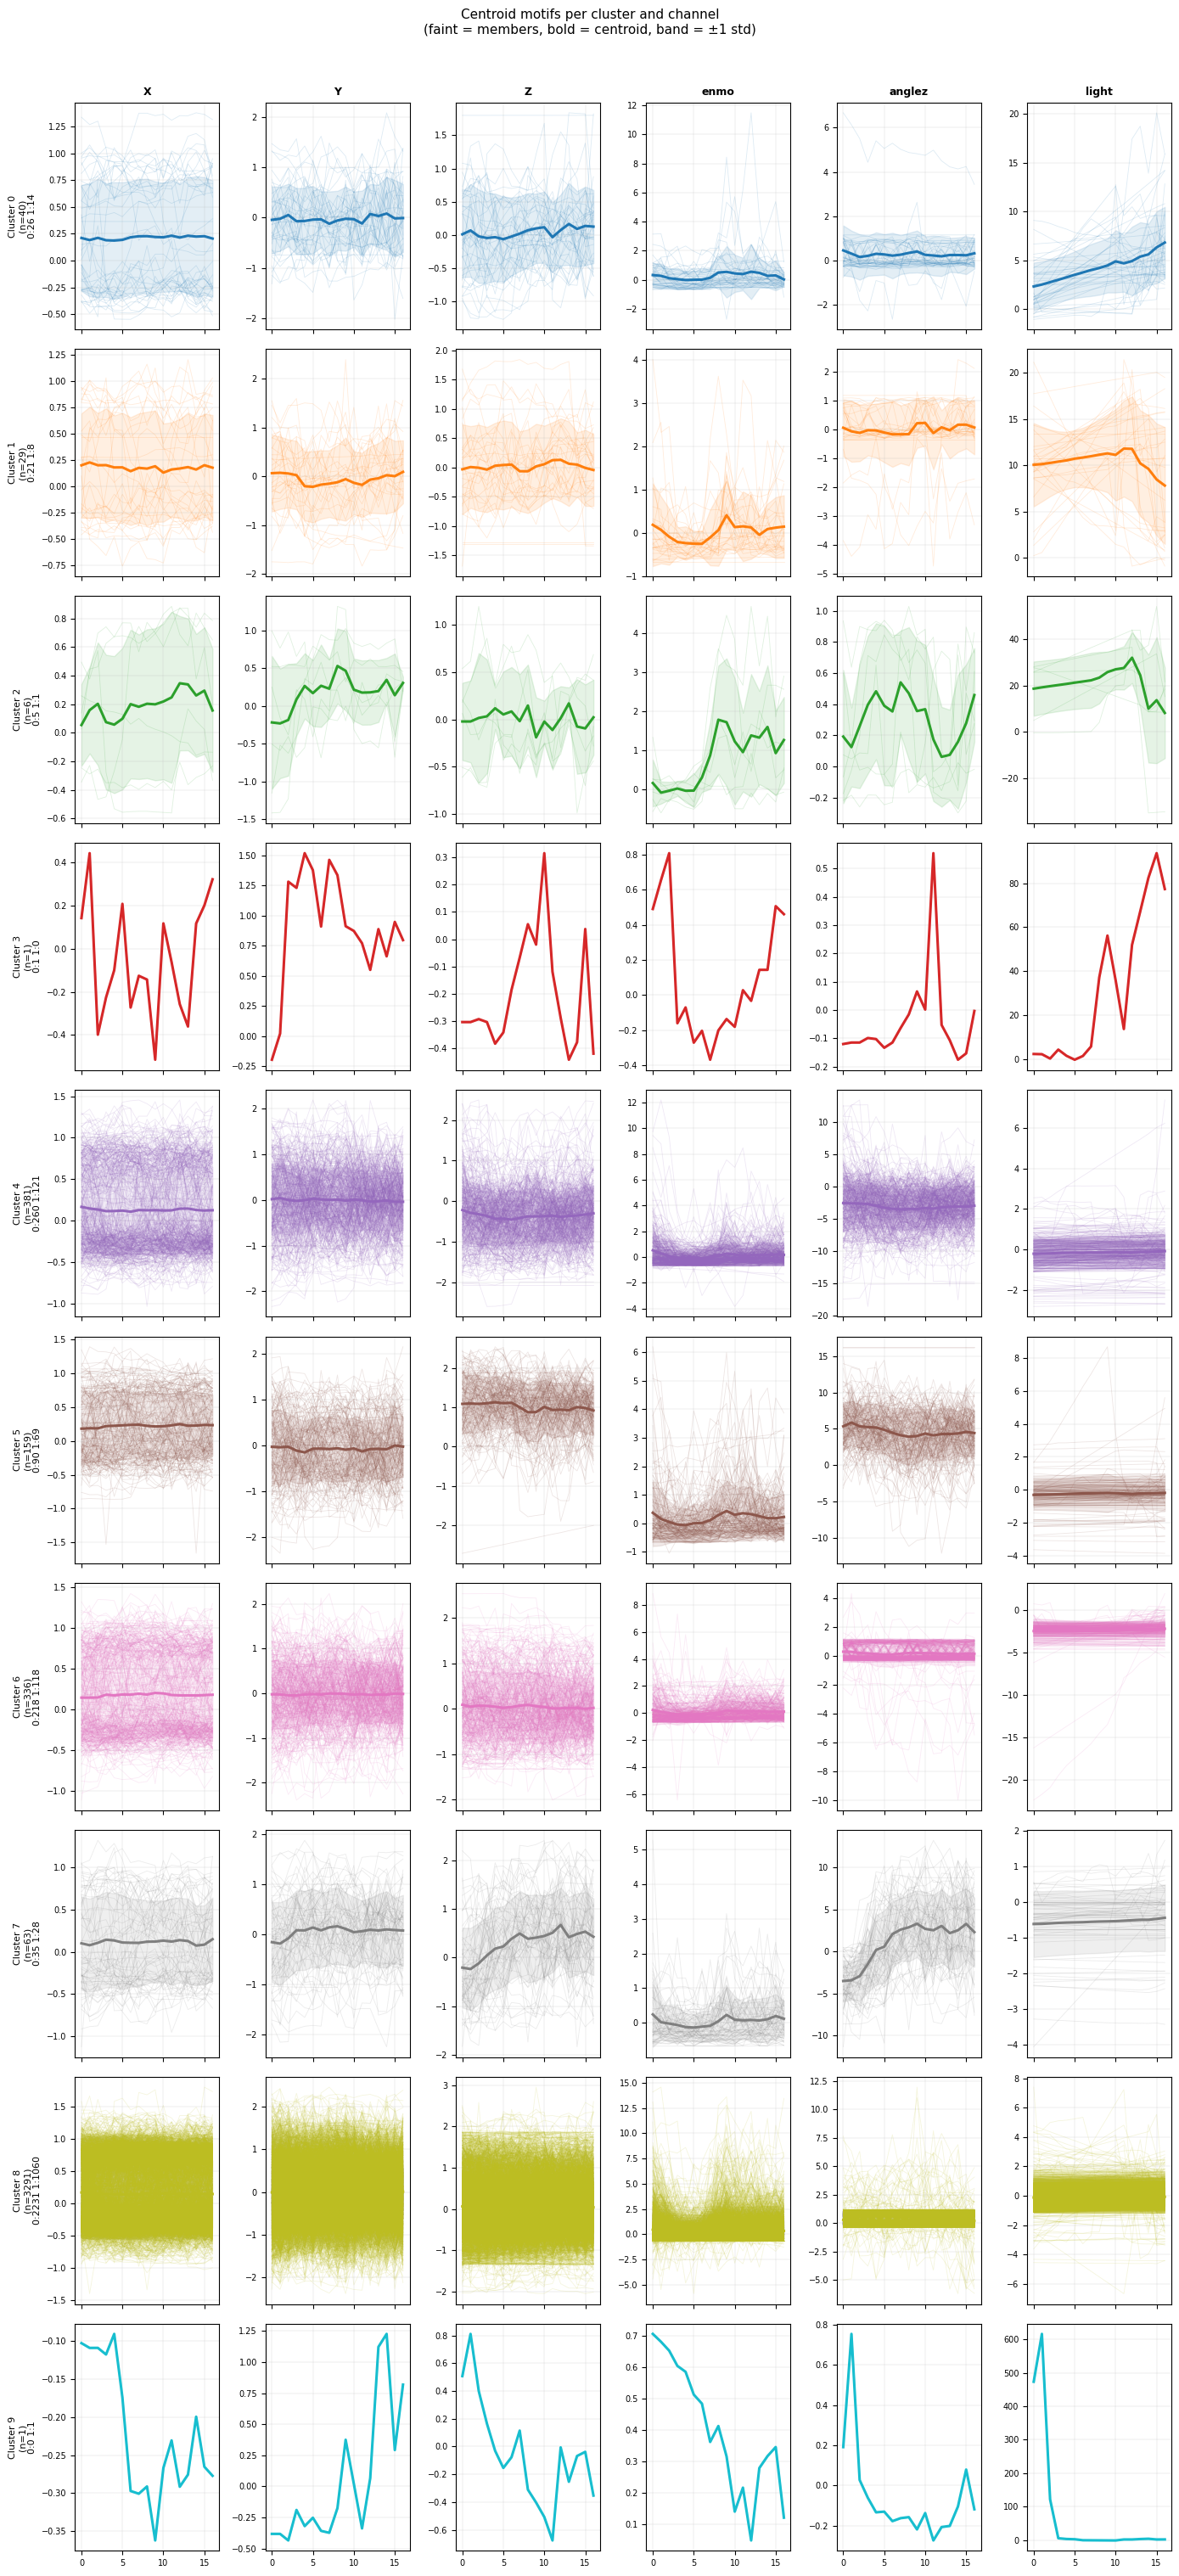

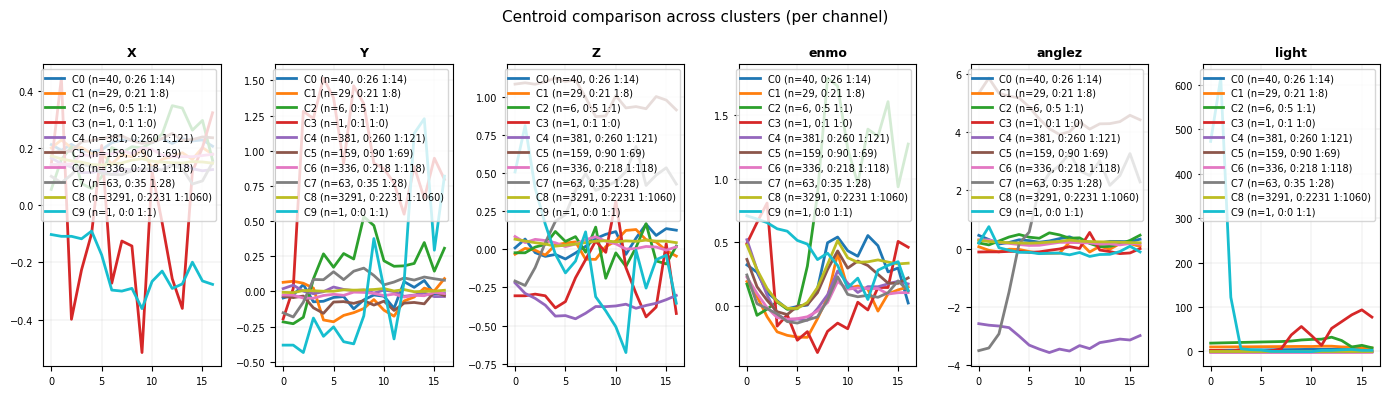

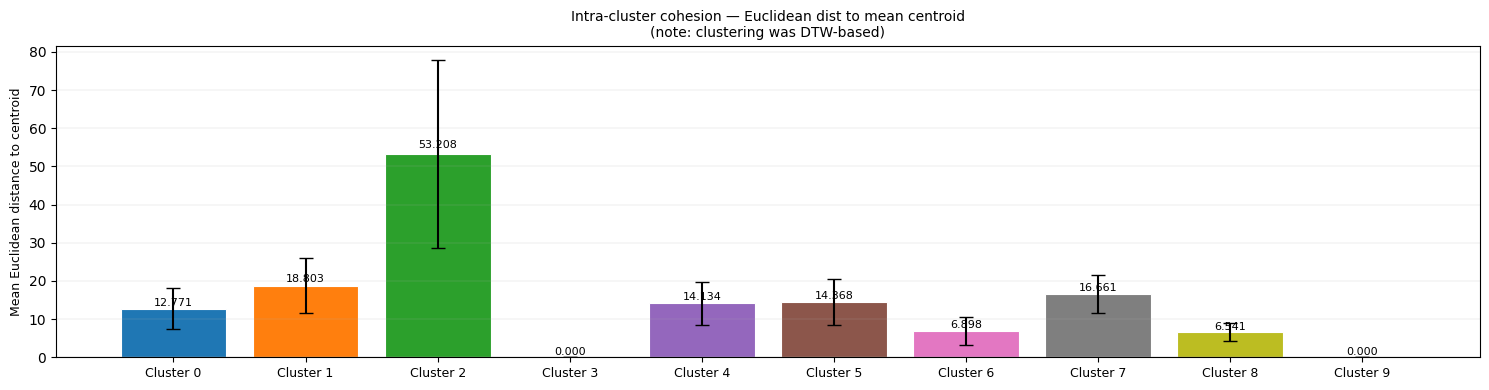

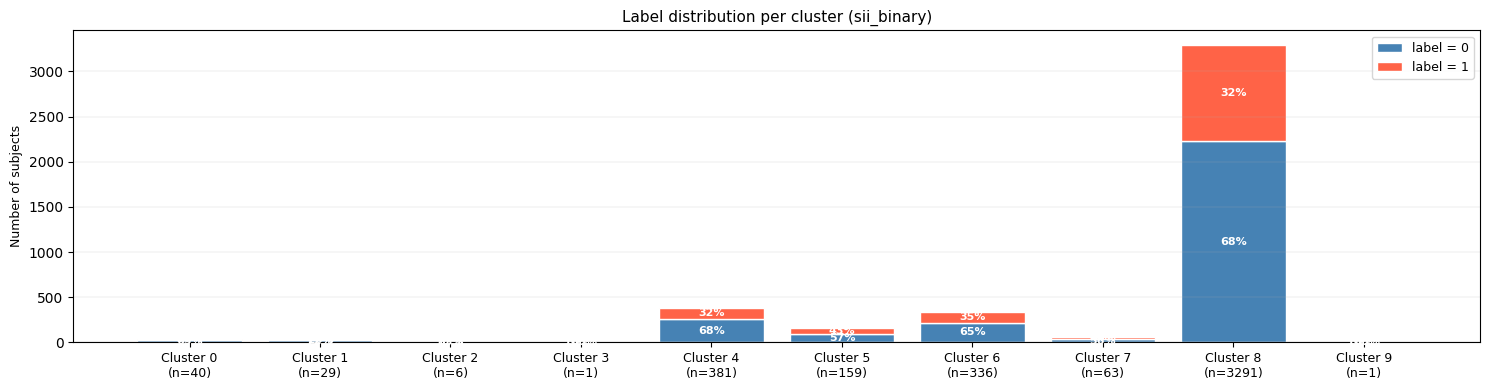

In [62]:
# Compute mean centroids from hierarchical cluster membership
centroids_hier = np.array([
    X_3d[motifs_df.loc[motifs_df["cluster_hier"] == c, "sample_index"].tolist()].mean(axis=0)
    for c in range(best_k)
])  # shape: (best_k, W, n_channels)


class FakeCentroids:
    def __init__(self, centers):          # ← __init__ (two underscores each side)
        self.cluster_centers_ = centers


intra_stats = characterize_clusters(
    motifs_df = motifs_df.rename(columns={"cluster_hier": "cluster"}),
    X_3d      = X_3d,
    km_final  = FakeCentroids(centroids_hier),
    CHANNELS  = CHANNELS,
    best_k    = best_k,
    y_labels  = y_labels.astype(int),
    save_path = "cluster_analysis.png",
)

## PCA + t-SNE

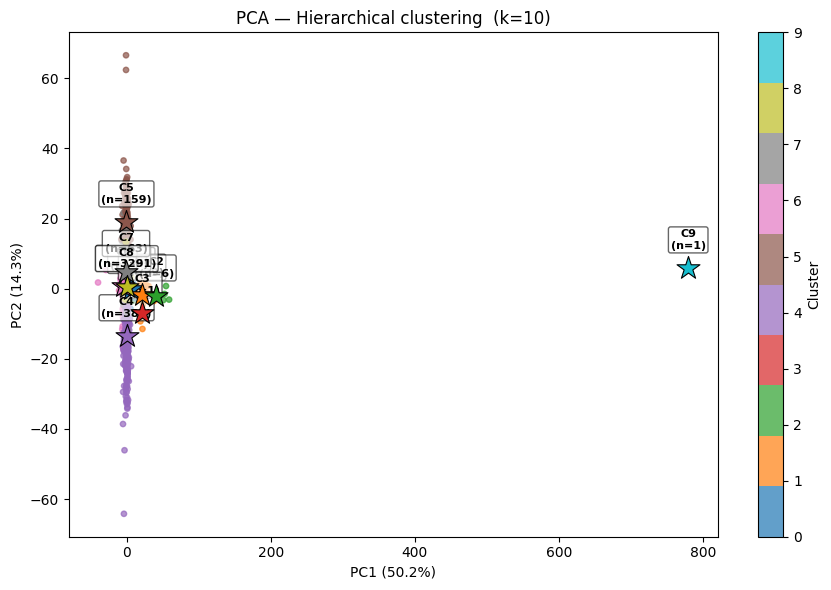

Running t-SNE ...


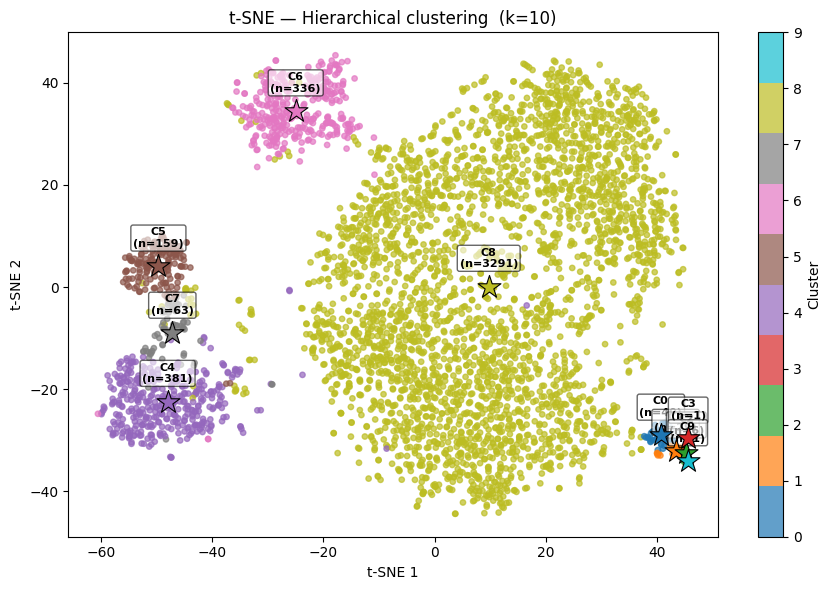

In [63]:
CMAP   = "tab10"
X_flat = X_3d.reshape(len(X_3d), -1)

# — PCA
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_flat)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=cluster_labels, cmap=CMAP, s=15, alpha=0.7,
                vmin=0, vmax=best_k - 1)
for c in range(best_k):
    mask = cluster_labels == c
    cx, cy = X_pca[mask, 0].mean(), X_pca[mask, 1].mean()
    ax.scatter(cx, cy, marker="*", s=300, c=[c], cmap=CMAP,
               vmin=0, vmax=best_k - 1, edgecolors="black", linewidths=0.8, zorder=5)
    ax.annotate(f"C{c}\n(n={mask.sum()})", (cx, cy),
                xytext=(0, 14), textcoords="offset points",
                fontsize=8, fontweight="bold", ha="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))
ax.set_title(f"PCA — Hierarchical clustering  (k={best_k})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.colorbar(sc, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

# — t-SNE (precomputed DTW distances)
print("Running t-SNE ...")
tsne   = TSNE(n_components=2, perplexity=30, random_state=42,
              metric="precomputed", init="random")
X_tsne = tsne.fit_transform(dist_mat)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=cluster_labels, cmap=CMAP, s=15, alpha=0.7,
                vmin=0, vmax=best_k - 1)
for c in range(best_k):
    mask = cluster_labels == c
    cx, cy = X_tsne[mask, 0].mean(), X_tsne[mask, 1].mean()
    ax.scatter(cx, cy, marker="*", s=300, c=[c], cmap=CMAP,
               vmin=0, vmax=best_k - 1, edgecolors="black", linewidths=0.8, zorder=5)
    ax.annotate(f"C{c}\n(n={mask.sum()})", (cx, cy),
                xytext=(0, 14), textcoords="offset points",
                fontsize=8, fontweight="bold", ha="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6))
ax.set_title(f"t-SNE — Hierarchical clustering  (k={best_k})")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
plt.colorbar(sc, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()

## UMAP

Running UMAP ...


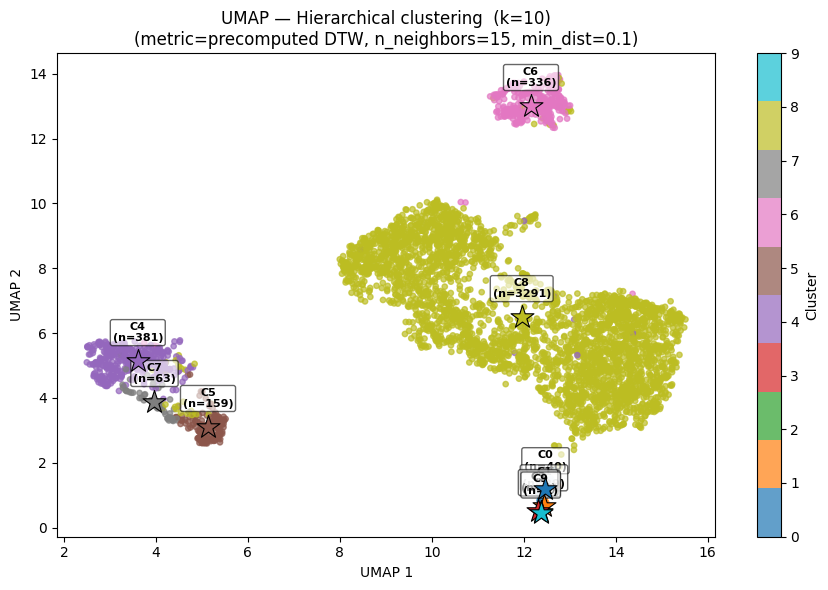

In [64]:
# — UMAP (precomputed DTW distances)
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn", "-q"])
    import umap

print("Running UMAP ...")
reducer  = umap.UMAP(
    n_components   = 2,
    metric         = "precomputed",
    n_neighbors    = 15,       # controls local vs global structure
    min_dist       = 0.1,      # how tightly points are packed
    random_state   = 42,
)
X_umap = reducer.fit_transform(dist_mat)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    X_umap[:, 0], X_umap[:, 1],
    c=cluster_labels, cmap=CMAP, s=15, alpha=0.7,
    vmin=0, vmax=best_k - 1,
)
for c in range(best_k):
    mask = cluster_labels == c
    cx, cy = X_umap[mask, 0].mean(), X_umap[mask, 1].mean()
    ax.scatter(
        cx, cy, marker="*", s=300, c=[c], cmap=CMAP,
        vmin=0, vmax=best_k - 1,
        edgecolors="black", linewidths=0.8, zorder=5,
    )
    ax.annotate(
        f"C{c}\n(n={mask.sum()})", (cx, cy),
        xytext=(0, 14), textcoords="offset points",
        fontsize=8, fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6),
    )
ax.set_title(f"UMAP — Hierarchical clustering  (k={best_k})\n"
             f"(metric=precomputed DTW, n_neighbors=15, min_dist=0.1)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.colorbar(sc, ax=ax, label="Cluster")
plt.tight_layout()
plt.show()